Modified from "Using Deep Learning for Flexible and Scalable Earthquake Forecasting"  
Reference: [Zenodo](https://zenodo.org/records/8161777)

In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import functools
import os
import importlib
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [2]:
checkpoint_dir  =  Path("../checkpoints/etas_20251222-205407") 
checkpoint_path1 = checkpoint_dir/ "best_model_1.pth"
checkpoint_dir2 = Path("../checkpoints/etas_20251221-224107") 
checkpoint_path2 = checkpoint_dir2/ "last_model_1.pth"

## Loading a trained model

In [3]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_and_prepare_model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model, args = load_and_prepare_model(checkpoint_path=checkpoint_path1,device=device)
# model2,_ = load_and_prepare_model(checkpoint_path=checkpoint_path2,device=device)

/root/autodl-tmp/chuandian_eq/src/models/tpp/etas.py:113: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("M_c", torch.tensor(mag_completeness))
/root/autodl-tmp/chuandian_eq/src/models/tpp/etas.py:114: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("b", torch.tensor(richter_b))


load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'etas', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'bg_model': 'mamba', 'bg_model_cfg': {'d_feature': 1, 'd_state': 64, 'd_model': 16, 'model_type': 'mamba', 'scale_init': 200.0}, 'bg_learning_rate': 0.0005, 'base_rate_init': 0.26, 'batch_size': 1, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.001, 'weight_decay': 0.01, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'step_warmup', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'dim': 1, 'epochs': 2000, 'save_dir': 'checkpoints/etas_20251222-205407', 'cuda_id': '0', 'dataset': 'PNR_1z', 'seed': 0, 'minibatch_training': False, 'split_by_time': True, 'time_order': ['train', 'val', 'test'], 'cuda': True, 'tau_mean': 0.10764365643262863, 'tau_min': 3.0597448130720295e-08, 'tau_max': 27.185277938842773, 'tau_q05': 0.

In [4]:
# model.bg_model = model2.bg_model

In [4]:
model.bg_model._scale

tensor(205.8691, device='cuda:0', grad_fn=<ExpBackward0>)

In [5]:
model.print_params()

ETAS model parameters:
  p = 1.6486139115885055
  c = 0.040131079200380865
  mu = 0.14570470283439646
  k = 0.01859481848339003
  alpha = 0.7630803372486291
  b = 1.1050430536270142
  M_c = -1.7999999523162842


## Loading the catalog

In [6]:
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw',catalog_file=None)

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/PNR_1z/raw.


In [7]:
catalog_ds.full_sequence

Sequence(
  inter_times: [12554],
  arrival_times: [12553],
  t_start: 0.0,
  t_end: 1541.0,
  t_nll_start: 0.0,
  mag: [12553],
  loc: [12553, 2],
  depth: [12553],
  time_series: [92435, 1],
  time_series_times: [92435]
)

## Prepare the data

We trained the TPP model using the `train` and `val` sequences. Now we will use the unseen section of the `test` sequence (in orange) to evaluate forecasting performance of the model.

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

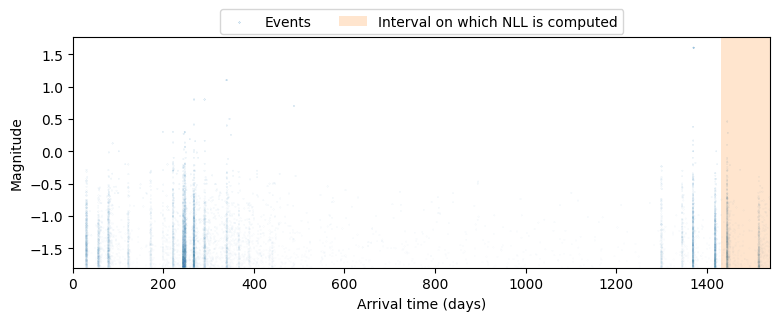

In [8]:
from src.utils.visualization import visualize_sequence
test_seq = catalog_ds.test[0]
train_seq = catalog_ds.train[0]
visualize_sequence(test_seq, show_nll=True)

In [9]:
test_batch = src.data.Batch.from_list([test_seq])
test_batch.to(device)
train_batch = src.data.Batch.from_list([train_seq])
train_batch.to(device)

Batch(
  inter_times: [1, 8327],
  arrival_times: [1, 8327],
  t_start: [1],
  t_end: [1],
  t_nll_start: [1],
  nll_event_mask: [1, 8327],
  input_mask: [1, 8327],
  start_idx: [1],
  end_idx: [1],
  non_pad_mask: [1, 8327],
  type_seq: [1, 8327],
  mag: [1, 8327],
  loc: [1, 8327, 2],
  depth: [1, 8327],
  time_series: [1, 54185, 1],
  time_series_times: [1, 54185]
)

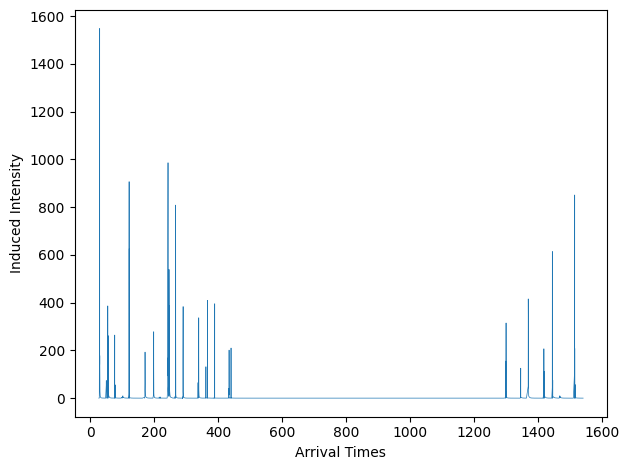

In [10]:
f_intensity= model.bg_model.intensity(test_batch)
plt.plot(
    test_batch.arrival_times.reshape(-1).detach().cpu().numpy(),
    f_intensity.reshape(-1).detach().cpu().numpy(),
    linewidth=0.5,
    color='tab:blue'
)
plt.xlabel('Arrival Times')
plt.ylabel('Induced Intensity')
plt.tight_layout()
plt.savefig(checkpoint_dir/'induced_intensity.png')

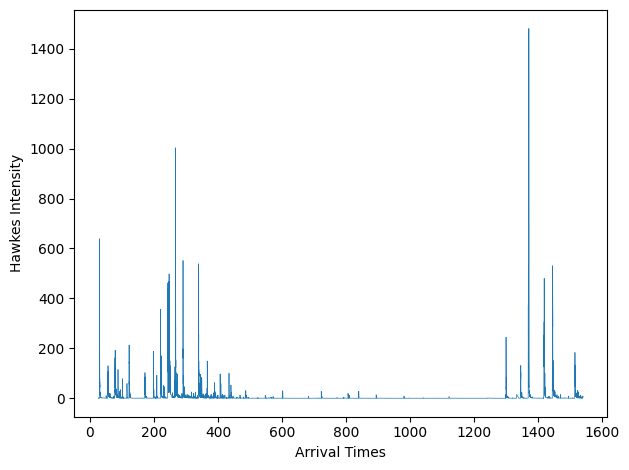

In [13]:
### rtpp
# context = model.get_context(test_batch)
# inter_time_dist = model.get_inter_time_dist(context)
# log_h_intensity = inter_time_dist.log_hazard(test_batch.inter_times.clamp_min(1e-10))
# h_intensity = torch.exp(log_h_intensity)
# h_intensity_copied = torch.where(h_intensity > 100000, torch.tensor(0.0, device=h_intensity.device), h_intensity)

# window = 20  # smoothing window size
# arrival_times_np = test_batch.arrival_times.detach().cpu().numpy().ravel()
# raw_np = h_intensity_copied.detach().cpu().numpy().ravel()
# smoothed = np.convolve(raw_np, np.ones(window) / window, mode='same')

# plt.xlabel('Arrival Times')
# plt.ylabel('History Intensity')
# # plt.plot(arrival_times_np, raw_np, linewidth=0.5, color='tab:blue', label='Raw')
# plt.plot(arrival_times_np, smoothed, linewidth=1.0, color='tab:red', label='Smoothed')
# plt.legend()
# plt.tight_layout()
### etas
h_intensity= model.h_intensity(test_batch)
plt.plot(
    test_batch.arrival_times.reshape(-1)[:-1].detach().cpu().numpy(),
    h_intensity.reshape(-1).detach().cpu().numpy(),
    linewidth=0.5,
    color='tab:blue'
)
plt.xlabel('Arrival Times')
plt.ylabel('Hawkes Intensity')
plt.tight_layout()
plt.savefig(checkpoint_dir/'hawkes_intensity.png')

In [ ]:
(h_intensity > 1000).sum().item()

5

5

We would like to generate a 30-day forecast for the interval `[13000, 13030]`. For this, we select two subsequences:
- `past_seq`: Contains events from `[0, 13000]`, is used to condition the model
- `observed_seq`: Contains actually observed events from `[13000, 13030]`.

In [15]:
t_forecast = 1430 # 1460
duration = 90 # 7 30
num_samples = 10000 # 10000

# Past events that we condition on
past_seq = test_seq.get_subsequence(0, t_forecast,reset_t_nll_to_end=True) #  3500
observed_seq = test_seq.get_subsequence(t_forecast, t_forecast + duration,reset_t_nll_to_end=True)

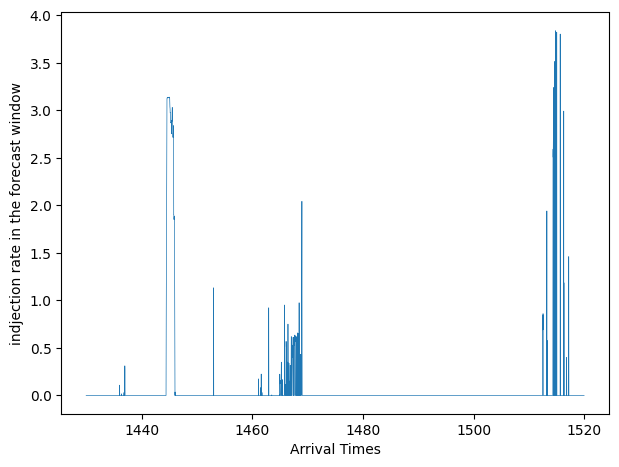

In [16]:
mask  = (test_seq.time_series_times >= t_forecast) & (test_seq.time_series_times < t_forecast + duration)
future_time_series = test_seq.time_series[mask]
future_time_series_times = test_seq.time_series_times[mask]
plt.xlabel('Arrival Times')
plt.ylabel('indjection rate in the forecast window')
plt.tight_layout()
plt.plot(future_time_series_times,
          future_time_series.reshape(-1).detach().cpu().numpy(),
           linewidth=0.5,
         color='tab:blue')

## Generate the forecast

In [17]:
past_batch = src.data.Batch.from_list([past_seq.float()])

In [18]:
past_seq

Sequence(
  inter_times: [10732],
  arrival_times: [10731],
  t_start: 0.0,
  t_end: 1430.0,
  t_nll_start: 1429.9,
  mag: [10731],
  loc: [10731, 2],
  depth: [10731],
  time_series: [85745, 1],
  time_series_times: [85745]
)

In [19]:
if torch.cuda.is_available():
    model.to('cuda:0')
    past_seq.to('cuda:0')

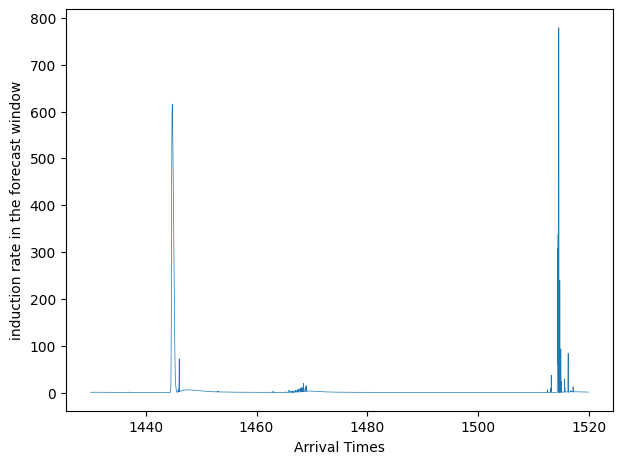

In [20]:
model.bg_model.cache_batch(time_series=test_seq.time_series.unsqueeze(0), time_series_times=test_seq.time_series_times.unsqueeze(0))
model.bg_model.ts_batch_cache
times_all = test_seq.time_series_times
mask = (times_all >= t_forecast) & (times_all < t_forecast + duration)
f_intensity = model.bg_model.intensity(ts_batch=model.bg_model.ts_batch_cache,t_query=times_all[mask].unsqueeze(0))
plt.xlabel('Arrival Times')
plt.ylabel('induction rate in the forecast window')
plt.tight_layout()
plt.plot(times_all[mask], f_intensity.reshape(-1).detach().cpu().numpy(), linewidth=0.5, color='tab:blue')

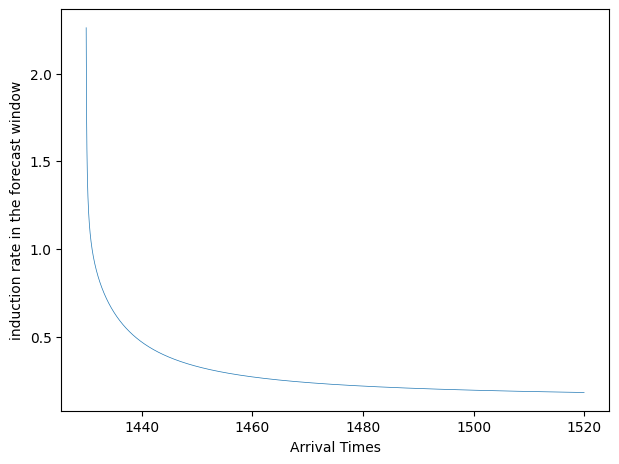

In [22]:
h_intensity = model.h_intensity(past_batch.to(device), t_query=times_all[mask].unsqueeze(0).to(device))
plt.xlabel('Arrival Times')
plt.ylabel('induction rate in the forecast window')
plt.tight_layout()
plt.plot(times_all[mask], h_intensity.reshape(-1).detach().cpu().numpy(), linewidth=0.5, color='tab:blue')

1683

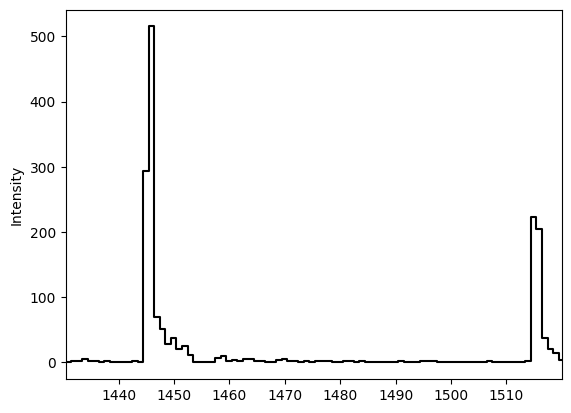

In [55]:
from src.utils.visualization import  plot_intensity
plot_intensity(observed_seq,dt=1)
len(observed_seq)

In [56]:
model.bg_model.cache_batch(time_series=test_seq.time_series.unsqueeze(0), time_series_times=test_seq.time_series_times.unsqueeze(0))

In [57]:
model.print_params()

ETAS model parameters:
  p = 1.6486139115885055
  c = 0.040131079200380865
  mu = 0.14570470283439646
  k = 0.01859481848339003
  alpha = 0.7630803372486291
  b = 1.1050430536270142
  M_c = -1.7999999523162842


In [58]:
# model.bg_model.set_scale(100)   
# model.bg_model._scale   
model.set_params(mu=0.14)

In [59]:
model.nll_loss(train_batch), model.nll_loss(test_batch)

intensity max: 1003.1402587890625, f_intensity max: 985.958740234375,mu max: 0.14
intensity max: 530.7357788085938, f_intensity max: 851.1104125976562,mu max: 0.14


(tensor([-30.2466], device='cuda:0', grad_fn=<DivBackward0>),
 tensor([-61.2253], device='cuda:0', grad_fn=<DivBackward0>))

In [60]:
set_seed(3) 
model.eval()  # Set the model to evaluation mode
all_forecasts = []
samples_per_batch = 10000
for _ in range(num_samples // samples_per_batch):
    # forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True, max_sample_len=4000)
    forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    all_forecasts.extend(forecast)

  0%|          | 0/10000 [00:00<?, ?it/s]

/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 11 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 7 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 8 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 4 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: Use

Exceeded 50000 events, discarding sequence


/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 18 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 18 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 16 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 17 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: 

Exceeded 50000 events, discarding sequence


/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 18 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(


  0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
zero_indices = []
for idx, fc in enumerate(all_forecasts):
    t = torch.as_tensor(fc.inter_times).cpu()
    if (t == 0).any():
        zero_indices.append(idx)

if zero_indices:
    print("Found zeros in inter_times at indices:", zero_indices)
else:
    print("No zeros found in inter_times of any forecast.")
print("Number of forecasts with zero inter_times:", len(zero_indices))

Found zeros in inter_times at indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 

`forecast` is a list, where each element is a `eq.data.Sequence` that represents a possible continuation of the catalog over the interval `[13000, 13030]`.

With the following function, we
- visualize 10 randomly chosen trajectories as a counting process
- plot the distribution of the total # of events in the forecast interval

In [62]:
model.bg_model.forecast_count(t_forecast, t_forecast + duration)
# model.bg_model.forecast_count(t_forecast+5, t_forecast + 10)

tensor(431.2339, device='cuda:0')

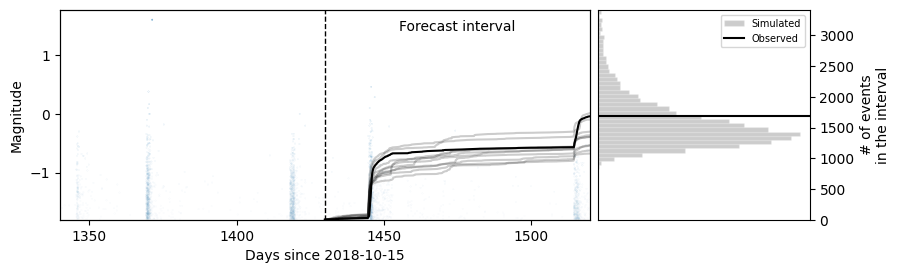

In [63]:
date_str = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d')
src.utils.visualization.visualize_trajectories(test_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.pdf",figsize=(10,3),xlabel='Days since '+date_str,reset_t_nll_to_end=True)

In [64]:
import  src.utils.catalog_tests as catalog_tests

In [65]:
test_seq

Sequence(
  inter_times: [12554],
  arrival_times: [12553],
  t_start: 0.0,
  t_end: 1541.0,
  t_nll_start: 1432.0,
  mag: [12553],
  loc: [12553, 2],
  depth: [12553],
  time_series: [92405, 1],
  time_series_times: [92405]
)

N-test

In [ ]:
number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=len(observed_seq),                   
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False
)
ax= number_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'n_test.pdf')

In [ ]:
mag_max = [all_forecasts[i].mag.max().item() for i in range(len(all_forecasts))]
mag_min = [all_forecasts[i].mag.min().item() for i in range(len(all_forecasts))]
max(mag_max), min(mag_min)

(4.534012021674942, -1.799999899103154)

In [ ]:
observed_seq.mag.max().item(), observed_seq.mag.min().item()

(0.46000000834465027, -1.7990000247955322)

M-test

In [ ]:
config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 5,
    'dmw': 0.01
}

magnitude_bins, distribution = catalog_tests.compute_magnitude_distribution(
    forecast[0].mag.cpu().numpy(), 
   **config_dict
)

In [ ]:
import matplotlib
importlib.reload(src.utils.catalog_tests)

<module 'src.utils.catalog_tests' from '/root/autodl-tmp/chuandian_eq/src/utils/catalog_tests.py'>

In [ ]:
get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts[:10],
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu()))[1],
    verbose=False,  
    debug=False
)

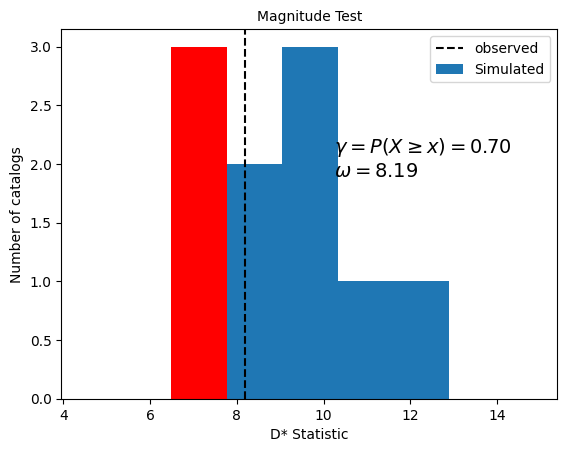

In [ ]:
magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
   obs_name='observed',
    sim_name='Simulated',
    plot=False
)
magnitude_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'m_test.pdf')

In [ ]:
start = int(test_seq.arrival_times[0].item())
end   = int(test_seq.arrival_times[-1].item())

duration = 12
slide_step = 12
quantiles = (2.5, 97.5)
samples_per_batch = 1000

t_forecast_list = range(start + duration, end - duration, slide_step)

counts_list = []
q_list = []
mean_list = []
forecasts_counts_list = []

model.eval()

for t_forecast in t_forecast_list:
        t_end = min(t_forecast + duration, end)

        past_seq = test_seq.get_subsequence(
            0, t_forecast, reset_t_nll_to_end=True
        ).to(device)
        observed_seq = test_seq.get_subsequence(
            t_forecast, t_end, reset_t_nll_to_end=True
        ).to(device)

        all_forecasts = model.sample(
            batch_size=samples_per_batch,
            duration=(t_end - t_forecast),
            past_seq=past_seq,
            return_sequences=True
        )

        forecasts_counts = np.fromiter((len(fc) for fc in all_forecasts), dtype=np.int32)

        q = np.percentile(forecasts_counts, quantiles)
        mean = forecasts_counts.mean()

        q_list.append(q)
        mean_list.append(mean)
        true_counts = len(observed_seq)
        counts_list.append(true_counts)
        forecasts_counts_list.append(forecasts_counts)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

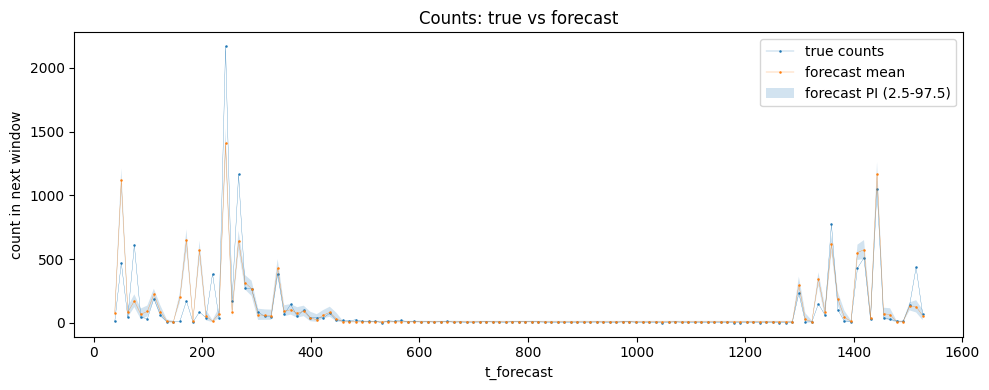

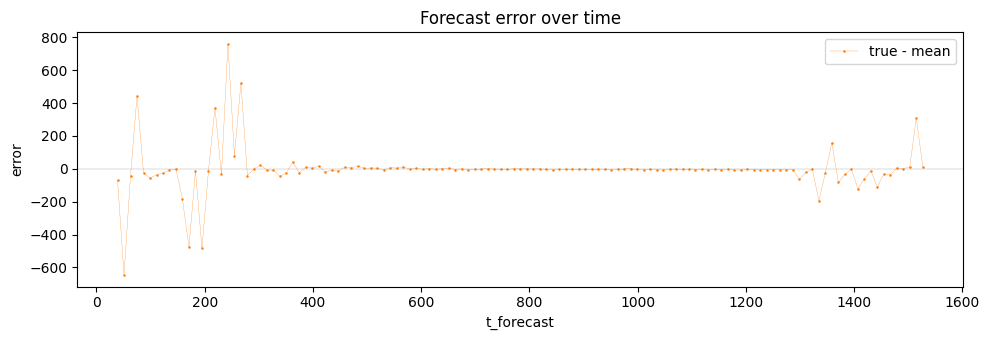

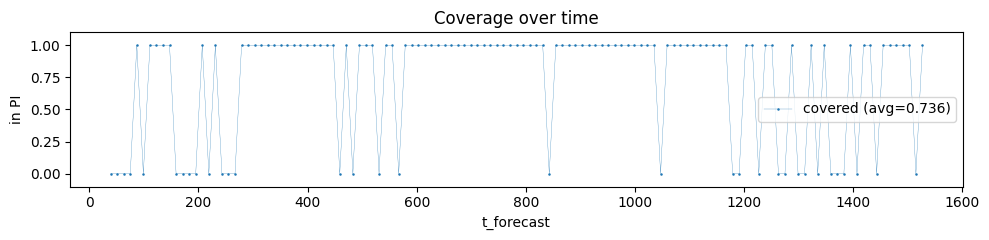

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array(list(t_forecast_list))
counts = np.array(counts_list)                  # shape: (T,)
means  = np.array(mean_list)                    # shape: (T,)
qs     = np.array(q_list)                       # shape: (T, 2)  -> [low, high]
q_low, q_high = qs[:, 0], qs[:, 1]

plt.figure(figsize=(10,4))
plt.plot(x, counts, label="true counts",linewidth=0.2,marker='o',markersize=0.8)
plt.plot(x, means,  label="forecast mean",linewidth=0.2,marker='o',markersize=0.8)
plt.fill_between(x, q_low, q_high, alpha=0.2, label="forecast PI (2.5-97.5)")
plt.xlabel("t_forecast")
plt.ylabel("count in next window")
plt.title("Counts: true vs forecast")
plt.legend()
plt.tight_layout()
plt.savefig(checkpoint_dir/'forecast_counts_over_time.png')
plt.show()

err = counts - means
plt.figure(figsize=(10,3.5))
plt.plot(x, err, label="true - mean",linewidth=0.2,marker='o',markersize=0.8,color='tab:orange')
plt.axhline(0,linewidth=0.2,color='gray')
plt.xlabel("t_forecast")
plt.ylabel("error")
plt.title("Forecast error over time")
plt.legend()
plt.tight_layout()
plt.savefig(checkpoint_dir/'forecast_error_over_time.png')
plt.show()


covered = (counts >= q_low) & (counts <= q_high)
coverage = covered.mean()
plt.figure(figsize=(10,2.5))
plt.plot(x, covered.astype(int), label=f"covered (avg={coverage:.3f})",linewidth=0.2,marker='o',markersize=0.8)
plt.ylim(-0.1, 1.1)
plt.xlabel("t_forecast")
plt.ylabel("in PI")
plt.title("Coverage over time")
plt.legend()
plt.tight_layout()
plt.show()
